# TASK : 5. Healthcare Patient Admission Trends

### Tech Stack :- Python , Pandas , Seaborn

### Description :- Process a public healthcare dataset tracking hospital admissions. Identify seasonal trends in patient visits and calculate the average length of stay per department, while handling outliers using statistical methods such as the IQR rule.

## LOAD LIBRARIES

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## LOAD DATASET

In [2]:
df = pd.read_csv("healthcare_dataset.csv")
df

,Patient_ID,Age,Gender,Height_cm,Weight_kg,BMI,Systolic_BP,Heart_Rate,Temperature,Oxygen_Level,...,Disease,Admission_Type,Hospital_Days,Medication,Recovery_Status,AQI,PM2_5,PM10,NO2,Mortality
0,P00001,20,Female,177,46,14.7,117,67,100.0,98,...,Heart Disease,Routine,4,Salbutamol,Critical,68,35,25,40,Yes
1,P00002,50,Female,177,117,37.3,164,60,97.3,99,...,Healthy,Emergency,6,NaN,Improving,35,60,96,24,Yes
2,P00003,38,Male,169,104,36.4,133,91,97.7,95,...,Healthy,Emergency,9,Amlodipine,Improving,53,24,63,17,Yes
3,P00004,33,Male,160,52,20.3,168,67,97.9,98,...,Asthma,Urgent,1,Amlodipine,Improving,119,131,91,32,Yes
4,P00005,76,Female,171,91,31.1,143,71,100.4,90,...,Heart Disease,Urgent,13,Metformin,Improving,115,34,79,72,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,P09996,29,Male,173,45,15.0,106,100,97.2,97,...,Asthma,Emergency,4,Atorvastatin,Recovered,175,136,70,16,No
9996,P09997,76,Female,195,50,13.1,128,101,98.4,90,...,Heart Disease,Urgent,9,NaN,Improving,53,130,111,8,Yes
9997,P09998,54,Male,165,111,40.8,145,64,99.5,96,...,COPD,Routine,8,NaN,Improving,187,128,200,20,No
9998,P09999,79,Female,170,67,23.2,157,96,99.2,98,...,Asthma,Emergency,7,NaN,Critical,184,17,97,58,Yes


## DISPLAY DATASET

In [3]:
df.head()

,Patient_ID,Age,Gender,Height_cm,Weight_kg,BMI,Systolic_BP,Heart_Rate,Temperature,Oxygen_Level,...,Disease,Admission_Type,Hospital_Days,Medication,Recovery_Status,AQI,PM2_5,PM10,NO2,Mortality
0,P00001,20,Female,177,46,14.7,117,67,100.0,98,...,Heart Disease,Routine,4,Salbutamol,Critical,68,35,25,40,Yes
1,P00002,50,Female,177,117,37.3,164,60,97.3,99,...,Healthy,Emergency,6,NaN,Improving,35,60,96,24,Yes
2,P00003,38,Male,169,104,36.4,133,91,97.7,95,...,Healthy,Emergency,9,Amlodipine,Improving,53,24,63,17,Yes
3,P00004,33,Male,160,52,20.3,168,67,97.9,98,...,Asthma,Urgent,1,Amlodipine,Improving,119,131,91,32,Yes
4,P00005,76,Female,171,91,31.1,143,71,100.4,90,...,Heart Disease,Urgent,13,Metformin,Improving,115,34,79,72,Yes


In [4]:
df.tail()

,Patient_ID,Age,Gender,Height_cm,Weight_kg,BMI,Systolic_BP,Heart_Rate,Temperature,Oxygen_Level,...,Disease,Admission_Type,Hospital_Days,Medication,Recovery_Status,AQI,PM2_5,PM10,NO2,Mortality
9995,P09996,29,Male,173,45,15.0,106,100,97.2,97,...,Asthma,Emergency,4,Atorvastatin,Recovered,175,136,70,16,No
9996,P09997,76,Female,195,50,13.1,128,101,98.4,90,...,Heart Disease,Urgent,9,NaN,Improving,53,130,111,8,Yes
9997,P09998,54,Male,165,111,40.8,145,64,99.5,96,...,COPD,Routine,8,NaN,Improving,187,128,200,20,No
9998,P09999,79,Female,170,67,23.2,157,96,99.2,98,...,Asthma,Emergency,7,NaN,Critical,184,17,97,58,Yes
9999,P10000,63,Male,151,102,44.7,144,62,97.9,93,...,Asthma,Urgent,9,Metformin,Critical,24,141,190,60,No


## DATASET INFORMATION

In [5]:
df.shape

(10000, 25)

In [6]:
df.columns

Index(['Patient_ID', 'Age', 'Gender', 'Height_cm', 'Weight_kg', 'BMI',
       'Systolic_BP', 'Heart_Rate', 'Temperature', 'Oxygen_Level', 'Glucose',
       'Cholesterol', 'Smoking', 'Alcohol', 'Exercise', 'Disease',
       'Admission_Type', 'Hospital_Days', 'Medication', 'Recovery_Status',
       'AQI', 'PM2_5', 'PM10', 'NO2', 'Mortality'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 25 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Patient_ID       10000 non-null  object 
 1   Age              10000 non-null  int64  
 2   Gender           10000 non-null  object 
 3   Height_cm        10000 non-null  int64  
 4   Weight_kg        10000 non-null  int64  
 5   BMI              10000 non-null  float64
 6   Systolic_BP      10000 non-null  int64  
 7   Heart_Rate       10000 non-null  int64  
 8   Temperature      10000 non-null  float64
 9   Oxygen_Level     10000 non-null  int64  
 10  Glucose          10000 non-null  int64  
 11  Cholesterol      10000 non-null  int64  
 12  Smoking          10000 non-null  object 
 13  Alcohol          10000 non-null  object 
 14  Exercise         10000 non-null  object 
 15  Disease          10000 non-null  object 
 16  Admission_Type   10000 non-null  object 
 17  Hospital_Days

In [8]:
df.describe()

,Age,Height_cm,Weight_kg,BMI,Systolic_BP,Heart_Rate,Temperature,Oxygen_Level,Glucose,Cholesterol,Hospital_Days,AQI,PM2_5,PM10,NO2
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,53.910900,170.055700,79.791800,28.221230,135.105800,84.704400,98.749850,95.043400,145.116700,210.051200,7.937600,109.554500,76.584400,115.508800,47.425000
std,21.076356,14.736265,23.400381,9.737804,20.613677,14.685264,1.010384,3.165836,43.483659,52.740428,4.315944,52.117813,42.306144,60.881795,24.812786
min,18.000000,145.000000,40.000000,10.600000,100.000000,60.000000,97.000000,90.000000,70.000000,120.000000,1.000000,20.000000,5.000000,10.000000,5.000000
25%,36.000000,157.000000,60.000000,20.400000,117.000000,72.000000,97.900000,92.000000,107.000000,163.000000,4.000000,64.000000,40.000000,63.000000,26.000000
50%,54.000000,170.000000,79.000000,27.300000,135.000000,85.000000,98.800000,95.000000,145.000000,210.000000,8.000000,110.000000,76.000000,116.000000,47.000000
75%,72.000000,183.000000,100.000000,34.700000,153.000000,97.000000,99.600000,98.000000,183.000000,256.000000,12.000000,154.250000,113.000000,168.000000,69.000000
max,90.000000,195.000000,120.000000,57.100000,170.000000,110.000000,100.500000,100.000000,220.000000,300.000000,15.000000,200.000000,150.000000,220.000000,90.000000


##  CHECK MISSING VALUES

In [9]:
df.isnull().sum()

Patient_ID            0
Age                   0
Gender                0
Height_cm             0
Weight_kg             0
BMI                   0
Systolic_BP           0
Heart_Rate            0
Temperature           0
Oxygen_Level          0
Glucose               0
Cholesterol           0
Smoking               0
Alcohol               0
Exercise              0
Disease               0
Admission_Type        0
Hospital_Days         0
Medication         1652
Recovery_Status       0
AQI                   0
PM2_5                 0
PM10                  0
NO2                   0
Mortality             0
dtype: int64

In [10]:
cat_cols=df.select_dtypes(include="object").columns

for col in cat_cols:
    df[col].fillna(df[col].mode()[0],inplace=True)

C:\Users\PALAk\AppData\Local\Temp\ipykernel_14544\1592615657.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0],inplace=True)


In [11]:
df.isnull().sum()

Patient_ID         0
Age                0
Gender             0
Height_cm          0
Weight_kg          0
BMI                0
Systolic_BP        0
Heart_Rate         0
Temperature        0
Oxygen_Level       0
Glucose            0
Cholesterol        0
Smoking            0
Alcohol            0
Exercise           0
Disease            0
Admission_Type     0
Hospital_Days      0
Medication         0
Recovery_Status    0
AQI                0
PM2_5              0
PM10               0
NO2                0
Mortality          0
dtype: int64

## DUPLICATE VALUES

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df.drop_duplicates(inplace=True)

In [14]:
print("Total Patients:",len(df))

Total Patients: 10000


## CALCULATE LENGTH OF STAY

In [15]:
df[["Hospital_Days", "Length_of_Stay"]].head()

KeyError: "['Length_of_Stay'] not in index"

## CHECK INVALID STAY 

In [ ]:
df[df["Length_of_Stay"] < 0]

# EXPLORATORY DATA ANALYSIS (EDA) 

## Total Number of Patients

In [16]:
total_patients = len(df)
print("Total Number of Patients:", total_patients)

Total Number of Patients: 10000


## Patient Admissions by Month

In [17]:
admission_counts = df["Admission_Type"].value_counts()
print(admission_counts)

Admission_Type
Urgent       3351
Routine      3339
Emergency    3310
Name: count, dtype: int64


## Seasonal Trend Visualization

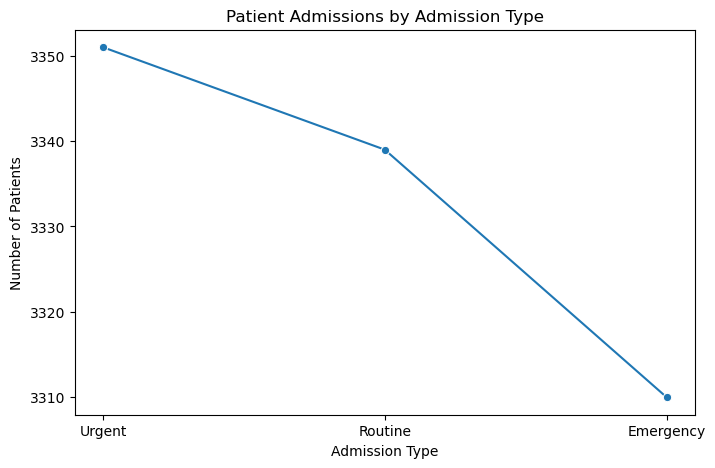

In [18]:
plt.figure(figsize=(8,5))

admission_counts = df["Admission_Type"].value_counts()

sns.lineplot(
    x=admission_counts.index,
    y=admission_counts.values,
    marker="o"
)

plt.title("Patient Admissions by Admission Type")
plt.xlabel("Admission Type")
plt.ylabel("Number of Patients")

plt.show()

## Admissions by Department

In [19]:
department_mapping = {
    "Hypertension": "Cardiology",
    "Heart Disease": "Cardiology",
    "Stroke": "Neurology",
    "Migraine": "Neurology",
    "Diabetes": "Endocrinology",
    "Asthma": "Pulmonology",
    "Pneumonia": "Pulmonology",
    "Tuberculosis": "Pulmonology",
    "Kidney Disease": "Nephrology",
    "Liver Disease": "Gastroenterology",
    "Arthritis": "Orthopedics",
    "Fracture": "Orthopedics",
    "Cancer": "Oncology",
    "COVID-19": "General Medicine",
    "Flu": "General Medicine"
}
df["Department"] = df["Disease"].map(department_mapping)
df["Department"] = df["Department"].fillna("General Medicine")

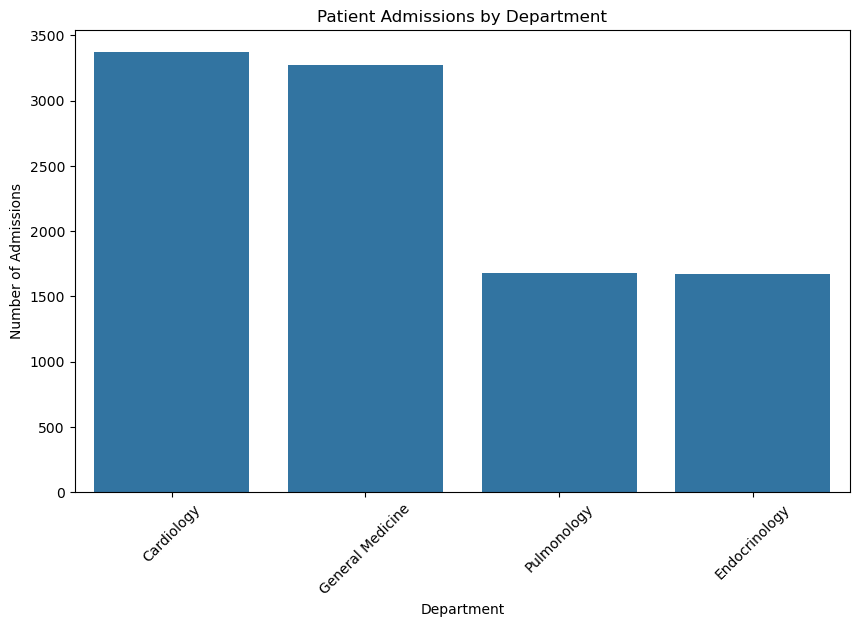

In [20]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=df,
    x="Department",
    order=df["Department"].value_counts().index
)

plt.title("Patient Admissions by Department")
plt.xlabel("Department")
plt.ylabel("Number of Admissions")

plt.xticks(rotation=45)

plt.show()

## Average Length of Stay

In [21]:
average_stay = df["Length_of_Stay"].mean()
print("Average Length of Stay:",round(average_stay, 2), "days")

KeyError: 'Length_of_Stay'

## Average Length of Stay by Department

In [22]:
average_stay_department = (
    df.groupby("Department")["Length_of_Stay"]
    .mean()
    .sort_values(ascending=False)
)
print(average_stay_department)

KeyError: 'Column not found: Length_of_Stay'

# Detect Outliers Using IQR Rule

## Calculate Q1, Q3, and IQR

In [47]:
Q1 = df["Hospital_Days"].quantile(0.25)
Q3 = df["Hospital_Days"].quantile(0.75)
IQR = Q3 - Q1
print("Q1 :", Q1)
print("Q3 :", Q3)
print("IQR:", IQR)

Q1 : 4.0
Q3 : 12.0
IQR: 8.0


## Calculate Lower and Upper Limits

In [48]:
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR
print("Lower Limit :", lower_limit)
print("Upper Limit :", upper_limit)

Lower Limit : -8.0
Upper Limit : 24.0


## Detect Outliers

In [49]:
outliers = df[
    (df["Hospital_Days"] < lower_limit) |
    (df["Hospital_Days"] > upper_limit)]
outliers

,Patient_ID,Age,Gender,Height_cm,Weight_kg,BMI,Systolic_BP,Heart_Rate,Temperature,Oxygen_Level,...,Hospital_Days,Medication,Recovery_Status,AQI,PM2_5,PM10,NO2,Mortality,Length_of_Stay,Department


## Count the Number of Outliers

In [50]:
print("Number of Outliers:", len(outliers))

Number of Outliers: 0


## Visualize Outliers Using a Box Plot

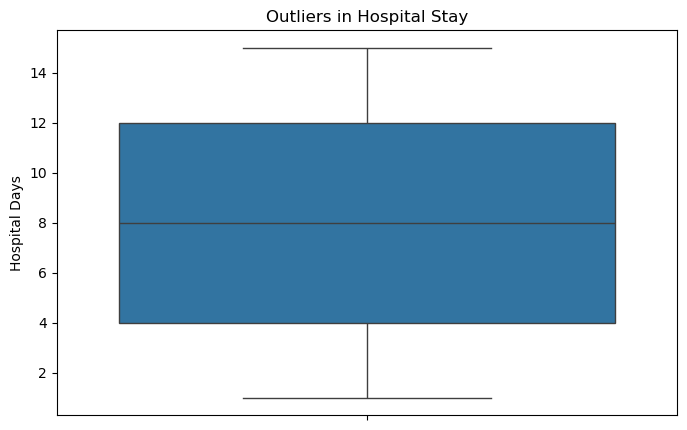

In [51]:
plt.figure(figsize=(8,5))

sns.boxplot(y=df["Hospital_Days"])

plt.title("Outliers in Hospital Stay")
plt.ylabel("Hospital Days")

plt.show()

## Remove Outliers

In [52]:
df_clean = df[
    (df["Hospital_Days"] >= lower_limit) &
    (df["Hospital_Days"] <= upper_limit)]
print("Original Dataset Shape :", df.shape)
print("Dataset Shape After Removing Outliers :", df_clean.shape)

Original Dataset Shape : (10000, 27)
Dataset Shape After Removing Outliers : (10000, 27)


## Display the Clean Dataset

In [53]:
df_clean.head()

,Patient_ID,Age,Gender,Height_cm,Weight_kg,BMI,Systolic_BP,Heart_Rate,Temperature,Oxygen_Level,...,Hospital_Days,Medication,Recovery_Status,AQI,PM2_5,PM10,NO2,Mortality,Length_of_Stay,Department
0,P00001,20,Female,177,46,14.7,117,67,100.0,98,...,4,Salbutamol,Critical,68,35,25,40,Yes,4,Cardiology
1,P00002,50,Female,177,117,37.3,164,60,97.3,99,...,6,Insulin,Improving,35,60,96,24,Yes,6,General Medicine
2,P00003,38,Male,169,104,36.4,133,91,97.7,95,...,9,Amlodipine,Improving,53,24,63,17,Yes,9,General Medicine
3,P00004,33,Male,160,52,20.3,168,67,97.9,98,...,1,Amlodipine,Improving,119,131,91,32,Yes,1,Pulmonology
4,P00005,76,Female,171,91,31.1,143,71,100.4,90,...,13,Metformin,Improving,115,34,79,72,Yes,13,Cardiology
